[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Model Accuracy: 0.87
              precision    recall  f1-score   support

    negative       0.73      0.68      0.70     16181
     neutral       0.51      0.19      0.28      8485
    positive       0.90      0.97      0.93     89025

    accuracy                           0.87    113691
   macro avg       0.71      0.61      0.64    113691
weighted avg       0.85      0.87      0.85    113691



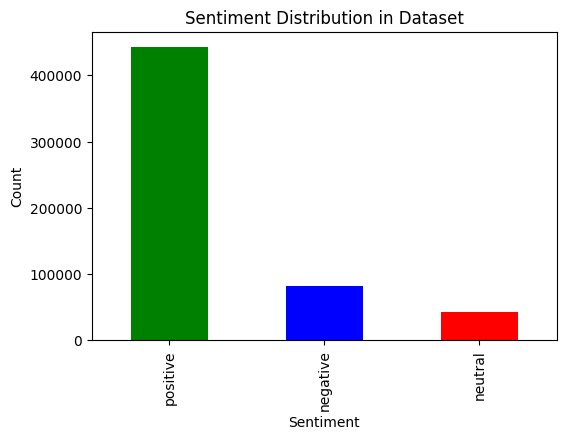

In [ ]:
import pandas as pd
import gzip
import re
import nltk
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# ✅ Fix: Download missing NLTK resources
nltk.download("punkt_tab")  # 🔹 Fix missing tokenizer issue
nltk.download("stopwords")  # 🔹 Ensures stopwords are available
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

# ✅ Step 2: Load Dataset Properly
file_path = "/content/finefoods.txt.gz"
with gzip.open(file_path, 'rt', encoding='ISO-8859-1') as f:
    data = f.readlines()

# ✅ Step 3: Extract Relevant Data
reviews, ratings = [], []
for line in data:
    if line.startswith("review/text:"):
        reviews.append(line.replace("review/text: ", "").strip())
    elif line.startswith("review/score:"):
        ratings.append(line.replace("review/score: ", "").strip())

df = pd.DataFrame({"review": reviews, "rating": ratings})
df["rating"] = df["rating"].astype(float)

# ✅ Step 4: Convert Ratings to Sentiment Labels
def categorize_sentiment(rating):
    return "positive" if rating >= 4.0 else "neutral" if rating == 3.0 else "negative"

df["sentiment"] = df["rating"].apply(categorize_sentiment)

# ✅ Step 5: Data Preprocessing (Clean Text)
stop_words = set(stopwords.words("english"))

def clean_text(text):
    text = text.lower()  # Lowercase
    text = re.sub(r"[^a-zA-Z\s]", "", text)  # Remove special characters
    words = word_tokenize(text)  # ✅ Fixed: Punkt tokenizer is now available
    words = [word for word in words if word not in stop_words]
    return " ".join(words)

df["cleaned_review"] = df["review"].apply(clean_text)

# ✅ Step 6: Train Model
X, y = df["cleaned_review"], df["sentiment"]
vectorizer = TfidfVectorizer(max_features=5000)
X_tfidf = vectorizer.fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(X_tfidf, y, test_size=0.2, random_state=42)
model = LogisticRegression()
model.fit(X_train, y_train)

# ✅ Step 7: Evaluate Model
y_pred = model.predict(X_test)
print(f"Model Accuracy: {accuracy_score(y_test, y_pred):.2f}")
print(classification_report(y_test, y_pred))

# ✅ Step 8: Visualize Sentiment Distribution
plt.figure(figsize=(6, 4))
df["sentiment"].value_counts().plot(kind="bar", color=["green", "blue", "red"])
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.title("Sentiment Distribution in Dataset")
plt.show()
